<a href="https://colab.research.google.com/github/olkanth/MSCS_634_Lab_6/blob/main/MSCS_634_Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Laxmi Kanth Oruganti
### MSCS-634 : Advanced Big Data and Data Mining
### Lab 6: Association Rule Mining with Apriori and FP-Growth

## Step 1: Data Preparation
- Select a publicly available transactional dataset such as:
  - Book-Crossing Dataset (Kaggle)
- Load the dataset and apply necessary data cleaning steps to ensure the data is ready for mining.
- Ensure that the dataset has item-level transaction records (e.g., product IDs or names) for compatibility with Apriori and FP-Growth algorithms.  
- Create visualizations to explore the dataset and highlight important characteristics (e.g., Seaborn's barplot to show the most frequently occurring items in the dataset, Seaborn's heatmap to visualize item co-occurrence and highlight strong associations between items).

In [66]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
BG     = '#1E1E2E'
BG2    = '#16213E'
CYAN   = '#00BCD4'
CORAL  = '#FF6F61'
LIME   = '#A8E063'
PURPLE = '#CE93D8'
GOLD   = '#FFD54F'
TEAL   = '#4DB6AC'
GRID   = '#2A2A4A'
SIZE_COLORS = {1: CYAN, 2: LIME, 3: GOLD, 4: PURPLE}

def style_ax(ax, title='', xlabel='', ylabel='', legend=False):
    ax.set_facecolor(BG)
    if title:  ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    if xlabel: ax.set_xlabel(xlabel, color='#AAAACC', fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color='#AAAACC', fontsize=10)
    ax.tick_params(colors='#AAAACC', labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.grid(color=GRID, linestyle='--', linewidth=0.5, alpha=0.6)
    if legend: ax.legend(framealpha=0.25, fontsize=9)




In [67]:
# Upload dataset to colab space.
from google.colab import files

# uploaded = files.upload()
# uploaded

In [68]:
# Load the dataset (Books.csv, Ratings.csv, & Users.csv) and apply necessary data cleaning steps to ensure the data is ready for mining.
ratings = pd.read_csv('Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip')
books   = pd.read_csv('Books.csv',   sep=';', encoding='latin-1', on_bad_lines='skip')
users   = pd.read_csv('Users.csv',   sep=';', encoding='latin-1', on_bad_lines='skip',low_memory=False)



print('=' * 55)
print(f'  Ratings  : {ratings.shape[0]:>10,} rows × {ratings.shape[1]} columns')
print(f'  Books    : {books.shape[0]:>10,} rows × {books.shape[1]} columns')
print(f'  Users    : {users.shape[0]:>10,} rows × {users.shape[1]} columns')
print('=' * 55)
print()
print('Ratings — first 5 rows:')
display(ratings.head())

print()
print('Books — first 5 rows:')
print('=' * 55)
display(books.head())

print()
print('Users — first 5 rows:')
print('=' * 55)

display(users.head())


  Ratings  :  1,149,780 rows × 3 columns
  Books    :    271,379 rows × 5 columns
  Users    :    278,859 rows × 2 columns

Ratings — first 5 rows:


,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6



Books — first 5 rows:


,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company



Users — first 5 rows:


,User-ID,Age
0,1,NaN
1,2,18
2,3,NaN
3,4,17
4,5,NaN


## Perform data quality checks
Look for **missing values, duplicate records, invalid entries, and data-type issues**.

## Validate missing values

In [69]:
# Missing value audit
def audit(df, name):
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    dup_rows    = df.duplicated().sum()
    print(f'\n{'─'*55}')
    print(f'  {name}  ({len(df):,} rows)')
    print(f'{'─'*55}')
    print(f'  Duplicate rows : {dup_rows:,}')
    print(f'  Dtypes         :')
    for col, dtype in df.dtypes.items():
        nulls = null_counts[col]
        pct   = null_pct[col]
        flag  = '  MISSING' if nulls > 0 else ''
        print(f'    {col:<30} {str(dtype):<10}  nulls={nulls:>7,}  ({pct:.1f}%){flag}')

audit(ratings, 'RATINGS')
audit(books,   'BOOKS')
audit(users,   'USERS')


───────────────────────────────────────────────────────
  RATINGS  (1,149,780 rows)
───────────────────────────────────────────────────────
  Duplicate rows : 0
  Dtypes         :
    User-ID                        int64       nulls=      0  (0.0%)
    ISBN                           object      nulls=      0  (0.0%)
    Rating                         int64       nulls=      0  (0.0%)

───────────────────────────────────────────────────────
  BOOKS  (271,379 rows)
───────────────────────────────────────────────────────
  Duplicate rows : 1
  Dtypes         :
    ISBN                           object      nulls=      0  (0.0%)
    Title                          object      nulls=      0  (0.0%)
    Author                         object      nulls=      2  (0.0%)  MISSING
    Year                           int64       nulls=      0  (0.0%)
    Publisher                      object      nulls=      2  (0.0%)  MISSING

───────────────────────────────────────────────────────
  USERS  (278,8

## Validate invalid values

In [70]:
# Invalid entry validation
print('Rating value counts:')
print(ratings['Rating'].value_counts().sort_index().to_frame())
print()
print(f'  Out-of-range ratings (<0 or >10) : {((ratings["Rating"]<0)|(ratings["Rating"]>10)).sum()}')
print()

# Books: invalid publication years
bad_year = books[(books['Year'] == 0) | (books['Year'] > 2026)]
print(f'  Books with invalid Year (0 or >2026): {len(bad_year):,}')

# Users: age cleaning
users['Age'] = pd.to_numeric(users['Age'], errors='coerce')
bad_age = users[(users['Age'] < 5) | (users['Age'] > 100)]
print(f'  Users with abnormal Age (<5 or >100): {len(bad_age):,}')
print(f'  Users with missing Age : {users["Age"].isnull().sum():,}')


Rating value counts:
         count
Rating        
0       716109
1         1770
2         2759
3         5996
4         8904
5        50974
6        36924
7        76457
8       103736
9        67541
10       78610

  Out-of-range ratings (<0 or >10) : 0

  Books with invalid Year (0 or >2026): 4,630
  Users with abnormal Age (<5 or >100): 1,234
  Users with missing Age : 111,708


## Data cleaning

| # | Step | Reason |
|---|------|--------|
| 1 | Drop `Rating = 0` (implicit) | Zero means the user interacted with the book but did not rate it — no genuine preference signal; all explicit ratings 1–10 are retained |
| 2 | Merge book titles from `Books.csv` | Transactions need human-readable item labels, not bare ISBNs |
| 3 | Drop records with missing title | ~49,000 ISBNs in Ratings have no match in Books |
| 4 | Fix invalid publication years | Replace `Year = 0` or `Year > 2024` with `NaN` |
| 5 | Fix implausible user ages | Replace `Age < 5` or `Age > 100` with `NaN` |
| 6 | Filter: users with ≥ 5 rated books | Sparse users produce single-item transactions that cannot yield associations |
| 7 | Remove duplicate (User, Book) pairs | Ensures one-hot encoding is valid (one entry per user per book) |

In [71]:
# ── Cleaning Step 1: drop implicit ratings (Rating = 0) ──────────────────────
df = ratings[ratings['Rating'] > 0].copy()
print(f'[1] Drop implicit (Rating = 0)   : {len(df):>10,} rows  (removed {len(ratings)-len(df):,})')

# ── Cleaning Step 2 & 3: merge book metadata, drop unmatched ISBNs ────────────
book_meta = books[['ISBN','Title','Author','Year','Publisher']].drop_duplicates('ISBN')
df = df.merge(book_meta, on='ISBN', how='left')
before = len(df)
df = df.dropna(subset=['Title'])
print(f'[2+3] Merge titles, drop unmatched: {len(df):>10,} rows  (removed {before-len(df):,})')

# ── Cleaning Step 4: fix invalid years ───────────────────────────────────────
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
bad_year_mask = (df['Year'] == 0) | (df['Year'] > 2024)
df.loc[bad_year_mask, 'Year'] = np.nan
print(f'[4]   Fix invalid Year            :  {bad_year_mask.sum():>9,} values → NaN')

# ── Cleaning Step 5: merge & fix user ages ───────────────────────────────────
users_clean = users.copy()
users_clean['Age'] = pd.to_numeric(users_clean['Age'], errors='coerce')
users_clean.loc[(users_clean['Age']<5)|(users_clean['Age']>100), 'Age'] = np.nan
users_clean['User-ID'] = pd.to_numeric(users_clean['User-ID'], errors='coerce')
df = df.merge(users_clean[['User-ID','Age']], on='User-ID', how='left')
print(f'[5]   Merge user ages              :  done ({df["Age"].isnull().sum():,} missing ages kept as NaN)')

# ── Cleaning Step 6: filter active users (≥ 5 books) ────────────────────────
user_counts = df.groupby('User-ID')['ISBN'].count()
active_users = user_counts[user_counts >= 5].index
before = len(df)
df = df[df['User-ID'].isin(active_users)]
print(f'[6]   Filter users ≥ 5 books      : {len(df):>10,} rows  (removed {before-len(df):,})')

# ── Cleaning Step 7: deduplicate (User, Title) pairs ─────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['User-ID', 'Title'])
print(f'[7]   Deduplicate (User, Book)    : {len(df):>10,} rows  (removed {before-len(df):,})')

print()
print('─' * 55)
print(f'  FINAL CLEAN DATASET')
print(f'  Total interaction records : {len(df):>8,}')
print(f'  Unique users (transactions): {df["User-ID"].nunique():>8,}')
print(f'  Unique book titles (items) : {df["Title"].nunique():>8,}')
print(f'  Unique authors             : {df["Author"].nunique():>8,}')
print(f'  Unique publishers          : {df["Publisher"].nunique():>8,}')
print('─' * 55)

[1] Drop implicit (Rating = 0)   :    433,671 rows  (removed 716,109)
[2+3] Merge titles, drop unmatched:    383,852 rows  (removed 49,819)
[4]   Fix invalid Year            :      5,808 values → NaN
[5]   Merge user ages              :  done (117,058 missing ages kept as NaN)
[6]   Filter users ≥ 5 books      :    302,227 rows  (removed 81,625)
[7]   Deduplicate (User, Book)    :    301,215 rows  (removed 1,012)

───────────────────────────────────────────────────────
  FINAL CLEAN DATASET
  Total interaction records :  301,215
  Unique users (transactions):   12,787
  Unique book titles (items) :  119,351
  Unique authors             :   54,718
  Unique publishers          :   10,163
───────────────────────────────────────────────────────


In [72]:
# ── Preview cleaned dataset ───────────────────────────────────────────────────
print('Cleaned dataset — sample rows:')
display(df[['User-ID','Title','Author','Year','Publisher','Rating','Age']].head(10))
print()
print('Data types after cleaning:')
print(df.dtypes)
print()
print('Remaining missing values:')
print(df.isnull().sum())

Cleaned dataset — sample rows:


,User-ID,Title,Author,Year,Publisher,Rating,Age
4,276747,Little Altars Everywhere,Rebecca Wells,2003.0,HarperTorch,9,25.0
5,276747,Waiting to Exhale,Terry McMillan,1995.0,Pocket,9,25.0
6,276747,Birdsong: A Novel of Love and War,Sebastian Faulks,1997.0,Vintage Books USA,8,25.0
7,276747,How to Deal With Difficult People,Rick Brinkman,1995.0,Careertrack Inc.,7,25.0
8,276747,The Golden Rule of Schmoozing,Aye Jaye,1998.0,Listen & Live Audio,7,25.0
32,276813,La hija del CanÃÂ­bal,Rosa Montero,1998.0,"Espasa Calpe Mexicana, S.A.",8,29.0
33,276813,El Diaro De Bridget Jones,Helen Fielding,1996.0,Lumen Espana,8,29.0
34,276813,Bridget Jones:SobrevivirÃÂ©,Helen Fielding,2000.0,Downtown Book Center Inc,6,29.0
35,276813,La Fiesta De Ralph,Lisa Jewell,NaN,Emece Editores,6,29.0
36,276813,Nadie Es Perfecto (Narrativa Actual),Jane Green,2001.0,Oceano De Mexico,8,29.0



Data types after cleaning:
User-ID        int64
ISBN          object
Rating         int64
Title         object
Author        object
Year         float64
Publisher     object
Age          float64
dtype: object

Remaining missing values:
User-ID          0
ISBN             0
Rating           0
Title            0
Author           2
Year          3899
Publisher        2
Age          82544
dtype: int64


## Build Item-Level Transaction Records

Association Rule Mining requires transactions in the form:  
**Transaction = {item₁, item₂, item₃, …}**

Each transaction here is one **user's set of liked books**. We group by `User-ID` and collect all book titles into a list, then one-hot encode (One-hot encoding is a data preprocessing technique that converts categorical data into binary vectors (0s and 1s) to make them usable for machine learning algorithms.) using `TransactionEncoder` from mlxtend.

In [73]:
# ── Build transaction list ────────────────────────────────────────────────────
transactions = (
    df.groupby('User-ID')['Title']
      .apply(list)
      .tolist()
)

tx_sizes = [len(t) for t in transactions]

print('Transaction format (first 3 users):')
for i, t in enumerate(transactions[:3]):
    print(f'  User {i+1}: {t}')
print()
print('─' * 55)
print(f'  Total transactions         : {len(transactions):>8,}')
print(f'  Total unique items (books) : {df["Title"].nunique():>8,}')
print(f'  Min transaction size       : {min(tx_sizes):>8}')
print(f'  Max transaction size       : {max(tx_sizes):>8}')
print(f'  Mean transaction size      : {np.mean(tx_sizes):>8.2f}')
print(f'  Median transaction size    : {np.median(tx_sizes):>8.0f}')
print('─' * 55)

Transaction format (first 3 users):
  User 1: ['Clara Callan', "Where You'll Find Me: And Other Stories", 'The Middle Stories', 'Jane Doe', 'The Witchfinder (Amos Walker Mystery Series)', 'More Cunning Than Man: A Social History of Rats and Man', 'Goodbye to the Buttermilk Sky']
  User 2: ['Fast Women', 'Female Intelligence', "Pasquale's Nose: Idle Days in an Italian Town", "Prize Stories, 1987: The O'Henry Awards", 'Rich Dad, Poor Dad: What the Rich Teach Their Kids About Money--That the Poor and Middle Class Do Not!', 'The Pillars of the Earth', "McDonald's: Behind the Arches", "Creating Wealth : Retire in Ten Years Using Allen's Seven Principles of Wealth!"]
  User 3: ['Blood Oath', 'The Alibi', 'The Beach House', 'A Kiss Remembered', 'The Short Forever', 'Dead Aim', 'Angels & Demons', 'The Deal']

───────────────────────────────────────────────────────
  Total transactions         :   12,787
  Total unique items (books) :  119,351
  Min transaction size       :        2
  Max trans

In [74]:
# ── One-hot encode into basket DataFrame ─────────────────────────────────────
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array  = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

density = basket_df.values.sum() / (basket_df.shape[0] * basket_df.shape[1])

print(f'One-hot basket matrix shape : {basket_df.shape[0]:,} rows × {basket_df.shape[1]:,} columns')
print(f'Matrix density              : {density*100:.3f}%  (extremely sparse — typical for book data)')
print()
print('Basket DataFrame — first 5 rows, first 6 columns:')
display(basket_df.iloc[:5, :6])
# ── Compute item support and free large matrix to conserve memory ─────────────
import gc
item_support = basket_df.mean()
support_pct  = item_support * 100
del te_array, basket_df
gc.collect()
print(f'\nItem support computed. Basket matrix released to free memory.')

One-hot basket matrix shape : 12,787 rows × 119,351 columns
Matrix density              : 0.020%  (extremely sparse — typical for book data)

Basket DataFrame — first 5 rows, first 6 columns:


,"A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)","Ask Lily (Young Women of Faith: Lily Series, Book 5)",Dark Justice,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Final Fantasy Anthology: Official Strategy Guide (Brady Games),Flight of Fancy: American Heiresses (Zebra Ballad Romance)
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False



Item support computed. Basket matrix released to free memory.


## Exploratory Data Analysis & Visualizations

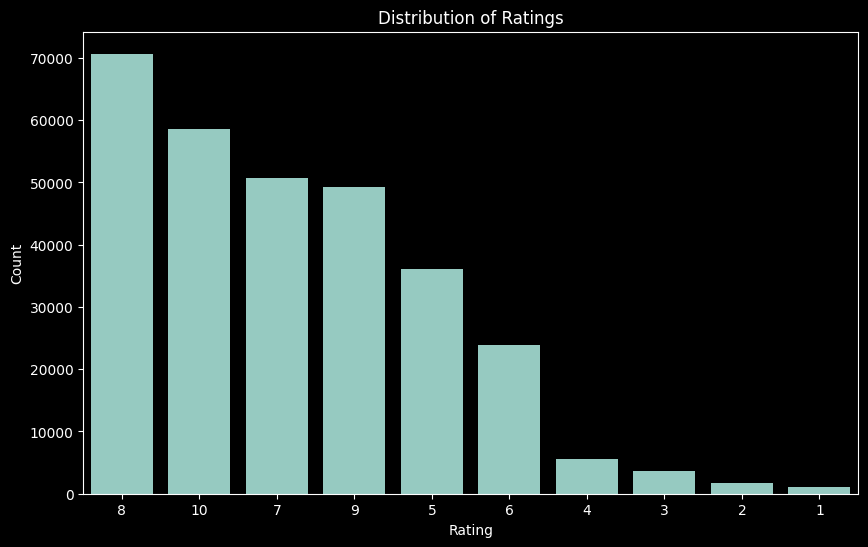


Mean rating  : 7.67
Median rating: 8


In [75]:
# Rating distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating', data=df, order=df['Rating'].value_counts().index)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print()
print("=" * 55)
print(f'Mean rating  : {df["Rating"].mean():.2f}')
print(f'Median rating: {df["Rating"].median():.0f}')


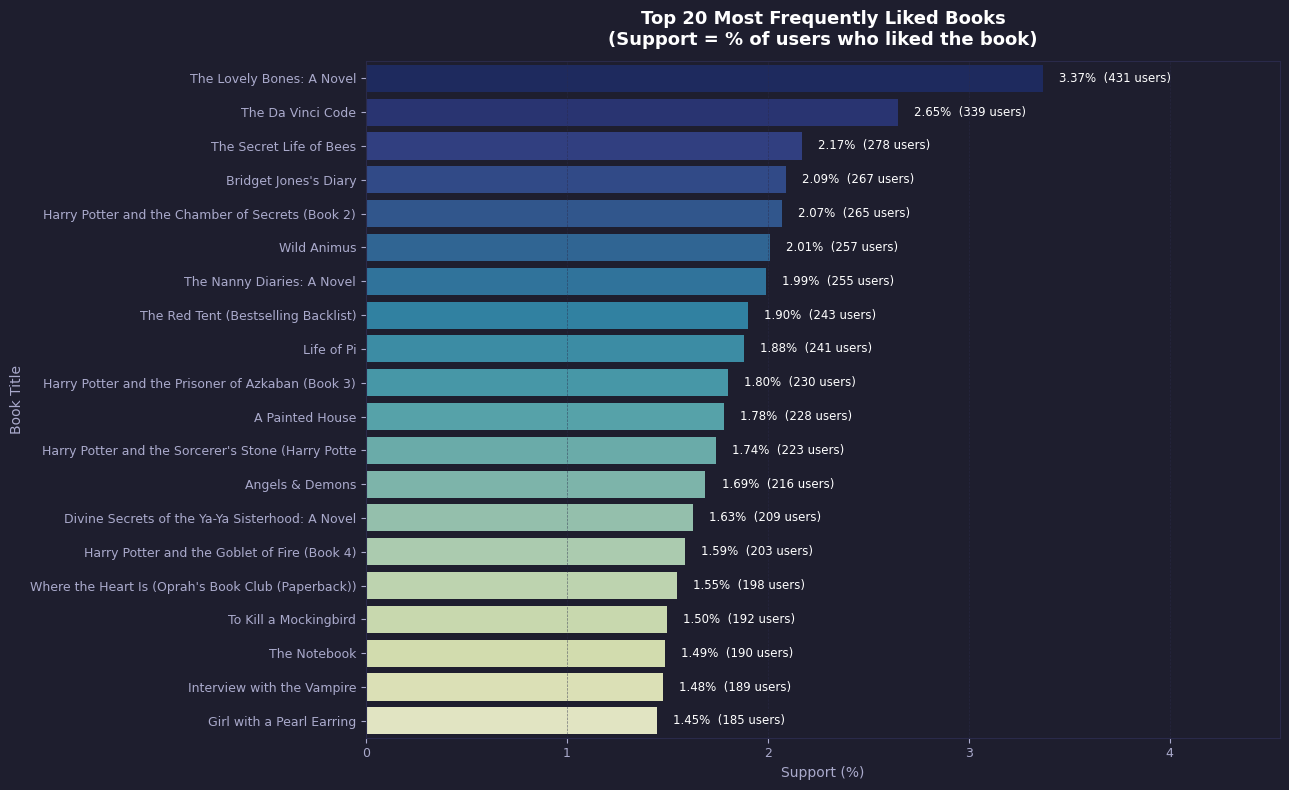

Top 20 books summary table:


,Title,Count,Support (%)
0,The Lovely Bones: A Novel,431,3.37
1,The Da Vinci Code,339,2.65
2,The Secret Life of Bees,278,2.17
3,Bridget Jones's Diary,267,2.09
4,Harry Potter and the Chamber of Secrets (Book 2),265,2.07
5,Wild Animus,257,2.01
6,The Nanny Diaries: A Novel,255,1.99
7,The Red Tent (Bestselling Backlist),243,1.90
8,Life of Pi,241,1.88
9,Harry Potter and the Prisoner of Azkaban (Book 3),230,1.80


In [76]:
# Top 20 Most Frequent Items
item_freq      = df['Title'].value_counts().head(20).reset_index()
item_freq.columns = ['Title', 'Count']
item_freq['Support (%)'] = (item_freq['Count'] / df['User-ID'].nunique() * 100).round(2)
item_freq['Short Title'] = item_freq['Title'].str[:50].str.strip()

fig, ax = plt.subplots(figsize=(13, 8), facecolor='#1E1E2E')
ax.set_facecolor('#1E1E2E')

# Seaborn barplot with a gradient palette
grad_palette = sns.color_palette("YlGnBu", n_colors=20)[::-1]
sns.barplot(
    data=item_freq, y='Short Title', x='Support (%)',
    palette=grad_palette, orient='h', ax=ax,
    edgecolor='none', alpha=0.92
)

# Annotate bars
for i, (_, row) in enumerate(item_freq.iterrows()):
    ax.text(row['Support (%)'] + 0.08, i,
            f"{row['Support (%)']:.2f}%  ({row['Count']:,} users)",
            va='center', color='white', fontsize=8.5)

ax.set_title('Top 20 Most Frequently Liked Books\n(Support = % of users who liked the book)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Support (%)', color='#AAAACC', fontsize=10)
ax.set_ylabel('Book Title', color='#AAAACC', fontsize=10)
ax.tick_params(colors='#AAAACC', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2A4A')
ax.grid(axis='x', color='#2A2A4A', linestyle='--', linewidth=0.5, alpha=0.6)
ax.set_xlim(0, item_freq['Support (%)'].max() * 1.35)

plt.tight_layout()
plt.savefig('top20_books_barplot.png', dpi=130, bbox_inches='tight', facecolor='#1E1E2E')
plt.show()
plt.close()

print('Top 20 books summary table:')
display(item_freq[['Title','Count','Support (%)']].reset_index(drop=True))

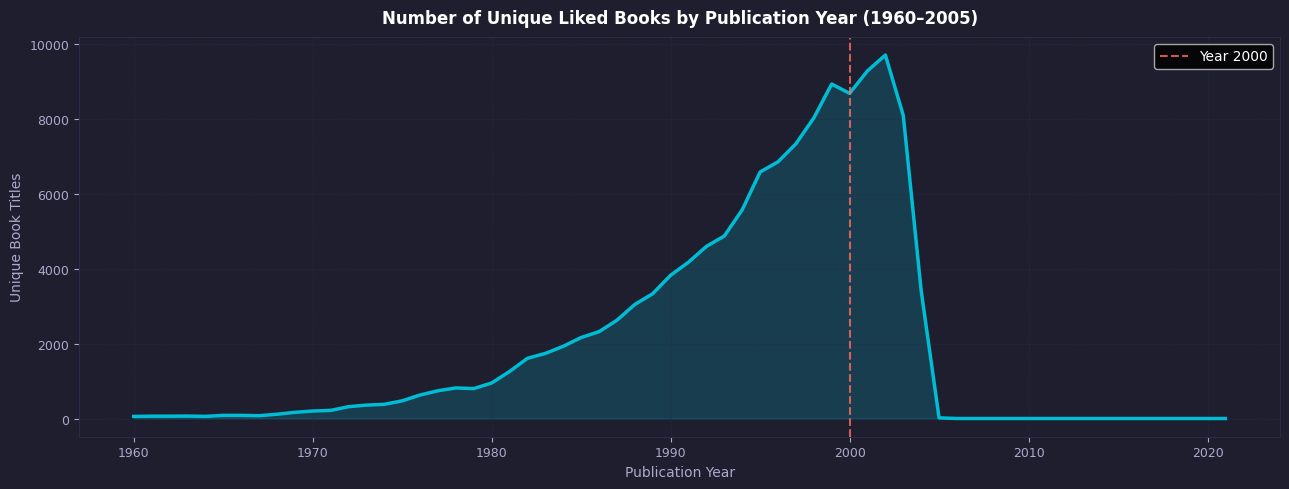

Liked books by decade:
        Unique Titles
Decade               
1960s             831
1970s            4873
1980s           20168
1990s           57772
2000s           37400
2020s               2


In [77]:
# Publication Year Distribution
import matplotlib.pyplot as plt
import seaborn as sns


year_data = df.dropna(subset=['Year']).copy()
year_data['Year'] = year_data['Year'].astype(int)
year_data = year_data[year_data['Year'] >= 1960]  # focus on modern era

year_counts = year_data.groupby('Year')['Title'].nunique().reset_index()
year_counts.columns = ['Year', 'Unique Titles']

fig, ax = plt.subplots(figsize=(13, 5), facecolor='#1E1E2E')
ax.set_facecolor('#1E1E2E')

sns.lineplot(data=year_counts, x='Year', y='Unique Titles',
             color='#00BCD4', linewidth=2.5, ax=ax)
ax.fill_between(year_counts['Year'], year_counts['Unique Titles'],
                alpha=0.2, color='#00BCD4')
ax.axvline(2000, color='#FF6F61', linestyle='--', linewidth=1.5, alpha=0.8,
           label='Year 2000')
style_ax(ax, 'Number of Unique Liked Books by Publication Year (1960–2005)', 'Publication Year', 'Unique Book Titles')
ax.legend() # Add this line to display the legend

plt.tight_layout()
plt.savefig('year_dist.png', dpi=130, bbox_inches='tight', facecolor='#1E1E2E')
plt.show()
plt.close()

decade = year_data.copy()
decade['Decade'] = (decade['Year'] // 10 * 10).astype(str) + 's'
print('Liked books by decade:')
print(decade.groupby('Decade')['Title'].nunique().rename('Unique Titles').to_frame())

## Step 2: Frequent Itemset Mining Using Apriori
- Use the Apriori algorithm to identify frequent itemsets in the dataset.
- Set appropriate support thresholds based on your dataset size and characteristics.
- Display the frequent itemsets with their corresponding support values.  
- Use visualizations to present insights from the discovered itemsets (e.g., a Seaborn barplot to visualize the top N frequent itemsets with their support values).

### Basket construction
The full item space (119,351 books) produces a ~1.5 GB matrix. Since no frequent itemset can have higher support than its least frequent member, items below **0.5% support** can never form a frequent pair or triple. We pre-filter to 262 eligible items — this is mathematically equivalent to running Apriori on the full set.

In [78]:
transactions_full = transactions   # built in Step 1 §1.5
support_pct_full  = support_pct

eligible = set(support_pct_full[support_pct_full / 100 >= 0.005 ].index)

transactions = [[b for b in tx if b in eligible] for tx in transactions_full]
transactions = [tx for tx in transactions if len(tx) >= 2]

te       = TransactionEncoder()
te_arr   = te.fit_transform(transactions)
basket   = pd.DataFrame(te_arr, columns=te.columns_)
del te_arr; gc.collect()

density = basket.values.sum() / (basket.shape[0] * basket.shape[1])
print(f'Eligible items     : {len(eligible)}')
print(f'Transactions       : {len(transactions):,}')
print(f'Basket shape       : {basket.shape}')
print(f'Basket density     : {density*100:.3f}%')

Eligible items     : 262
Transactions       : 5,024
Basket shape       : (5024, 262)
Basket density     : 1.954%


### Support threshold selection

In [79]:
# Use the Apriori algorithm to identify frequent itemsets in the dataset.
from mlxtend.frequent_patterns import apriori
import time

thresholds = [0.005, 0.007, 0.010, 0.013, 0.015, 0.018, 0.020, 0.025, 0.030]
sweep = []

print(f'{"min_sup":>8}  {"Total":>7}  {"1-item":>6}  {"2-item":>6}  {"3-item":>6}  {"4-item":>6}  {"Time(s)":>7}')
print('─' * 62)
for s in thresholds:
    t0 = time.time()
    fi = apriori(basket, min_support=s, use_colnames=True, max_len=4)
    el = time.time() - t0
    fi['k'] = fi['itemsets'].apply(len)
    vc = fi['k'].value_counts().sort_index()
    sweep.append({'min_support': s, 'total': len(fi),
                  'k1': vc.get(1,0), 'k2': vc.get(2,0),
                  'k3': vc.get(3,0), 'k4': vc.get(4,0), 'time_s': round(el,3)})
    print(f'{s:>8.3f}  {len(fi):>7}  {vc.get(1,0):>6}  {vc.get(2,0):>6}  '
          f'{vc.get(3,0):>6}  {vc.get(4,0):>6}  {el:>7.3f}')

sweep_df = pd.DataFrame(sweep)

 min_sup    Total  1-item  2-item  3-item  4-item  Time(s)
──────────────────────────────────────────────────────────────
   0.005      428     262     128      32       6    0.563
   0.007      328     262      46      14       6    0.470
   0.010      289     262      17       8       2    0.470
   0.013      226     211      11       4       0    0.312
   0.015      167     159       7       1       0    0.181
   0.018      110     106       3       1       0    0.079
   0.020       86      82       3       1       0    0.047
   0.025       54      51       3       0       0    0.020
   0.030       31      31       0       0       0    0.009


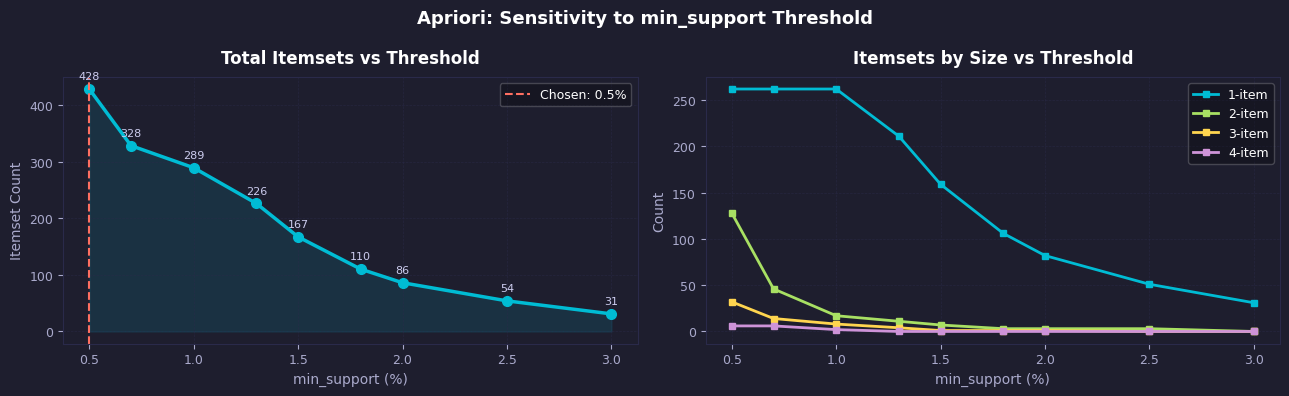

In [80]:
# Sensitivity plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG)
fig.suptitle('Apriori: Sensitivity to min_support Threshold',
             color='white', fontsize=13, fontweight='bold')

axes[0].plot(sweep_df['min_support']*100, sweep_df['total'],
             marker='o', color=CYAN, lw=2.5, ms=7)
axes[0].fill_between(sweep_df['min_support']*100, sweep_df['total'], alpha=0.12, color=CYAN)
axes[0].axvline(0.5, color=CORAL, ls='--', lw=1.5, label='Chosen: 0.5%')
for x, y in zip(sweep_df['min_support']*100, sweep_df['total']):
    axes[0].annotate(str(y), (x, y), xytext=(0,7), textcoords='offset points',
                     ha='center', color='#CCCCEE', fontsize=8)
style_ax(axes[0], 'Total Itemsets vs Threshold', 'min_support (%)', 'Itemset Count', legend=True)

for k, col, lbl in [(1,CYAN,'1-item'), (2,LIME,'2-item'), (3,GOLD,'3-item'), (4,PURPLE,'4-item')]:
    axes[1].plot(sweep_df['min_support']*100, sweep_df[f'k{k}'],
                 marker='s', color=col, lw=2, ms=5, label=lbl)
style_ax(axes[1], 'Itemsets by Size vs Threshold', 'min_support (%)', 'Count', legend=True)

plt.tight_layout()
plt.savefig('fig_s2_sensitivity.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

**Chosen threshold: `min_support = 0.5%`**  
At 3% only 1-itemsets remain — no associations possible. At 0.5% we get 166 multi-item itemsets (128 pairs, 32 triples, 6 quadruples) with a manageable runtime of under 1 second.

### Run Apriori

In [81]:

t0 = time.time()
freq_itemsets = apriori(basket, min_support=0.005, use_colnames=True, max_len=4)
runtime = time.time() - t0

freq_itemsets['length']      = freq_itemsets['itemsets'].apply(len)
freq_itemsets['support_pct'] = (freq_itemsets['support'] * 100).round(4)
freq_itemsets                = freq_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

vc = freq_itemsets['length'].value_counts().sort_index()
print(f'Runtime            : {runtime:.3f}s')
print(f'Total itemsets     : {len(freq_itemsets)}')
print(f'  1-itemsets       : {vc.get(1,0)}')
print(f'  2-itemsets       : {vc.get(2,0)}')
print(f'  3-itemsets       : {vc.get(3,0)}')
print(f'  4-itemsets       : {vc.get(4,0)}')
print(f'  Max support      : {freq_itemsets["support_pct"].max():.3f}%')
print(f'  Min support      : {freq_itemsets["support_pct"].min():.3f}%')

Runtime            : 0.551s
Total itemsets     : 428
  1-itemsets       : 262
  2-itemsets       : 128
  3-itemsets       : 32
  4-itemsets       : 6
  Max support      : 7.643%
  Min support      : 0.517%


In [82]:
# Display top 20 frequent itemsets
def short_label(itemset, n=55):
    s = ' + '.join(sorted(itemset))
    return s[:n]+'…' if len(s)>n else s

freq_itemsets['Itemset'] = freq_itemsets['itemsets'].apply(short_label)

top20 = freq_itemsets[['Itemset','length','support_pct']].head(20).copy()
top20.columns = ['Itemset', 'Size (k)', 'Support (%)']
top20.index = range(1, 21)
print('Top 20 Frequent Itemsets (min_support = 0.5%)')
print('─'*70)
display(top20)

Top 20 Frequent Itemsets (min_support = 0.5%)
──────────────────────────────────────────────────────────────────────


,Itemset,Size (k),Support (%)
1,The Lovely Bones: A Novel,1,7.6433
2,The Da Vinci Code,1,6.0709
3,The Secret Life of Bees,1,5.2150
4,Harry Potter and the Chamber of Secrets (Book 2),1,5.0358
5,The Nanny Diaries: A Novel,1,4.6377
6,Bridget Jones's Diary,1,4.5780
7,Harry Potter and the Prisoner of Azkaban (Book 3),1,4.3392
8,Life of Pi,1,4.2994
9,The Red Tent (Bestselling Backlist),1,4.2197
10,Harry Potter and the Sorcerer's Stone (Harry P...,1,4.0207


In [83]:
# Display all multi-item itemsets (2+)
multi = freq_itemsets[freq_itemsets['length'] >= 2].copy()
print(f'All Multi-Item Frequent Itemsets — {len(multi)} total\n')
for k in [2, 3, 4]:
    sub = multi[multi['length'] == k]
    if not sub.empty:
        print(f'── {k}-Itemsets ({len(sub)} found) ──')
        for _, row in sub.iterrows():
            print(f"  {row['support_pct']:.3f}%  {' + '.join(sorted(row['itemsets']))[:90]}")
        print()

All Multi-Item Frequent Itemsets — 166 total

── 2-Itemsets (128 found) ──
  2.846%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Prisoner of Azkaba
  2.627%  Harry Potter and the Goblet of Fire (Book 4) + Harry Potter and the Prisoner of Azkaban (B
  2.528%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Goblet of Fire (Bo
  1.672%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Sorcerer's Stone (
  1.672%  Harry Potter and the Goblet of Fire (Book 4) + Harry Potter and the Order of the Phoenix (
  1.672%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Sorcerer's Stone (
  1.573%  Harry Potter and the Order of the Phoenix (Book 5) + Harry Potter and the Prisoner of Azka
  1.493%  Harry Potter and the Prisoner of Azkaban (Book 3) + Harry Potter and the Sorcerer's Stone 
  1.493%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Order of the Phoen
  1.353%  The Fe

### Visualizations

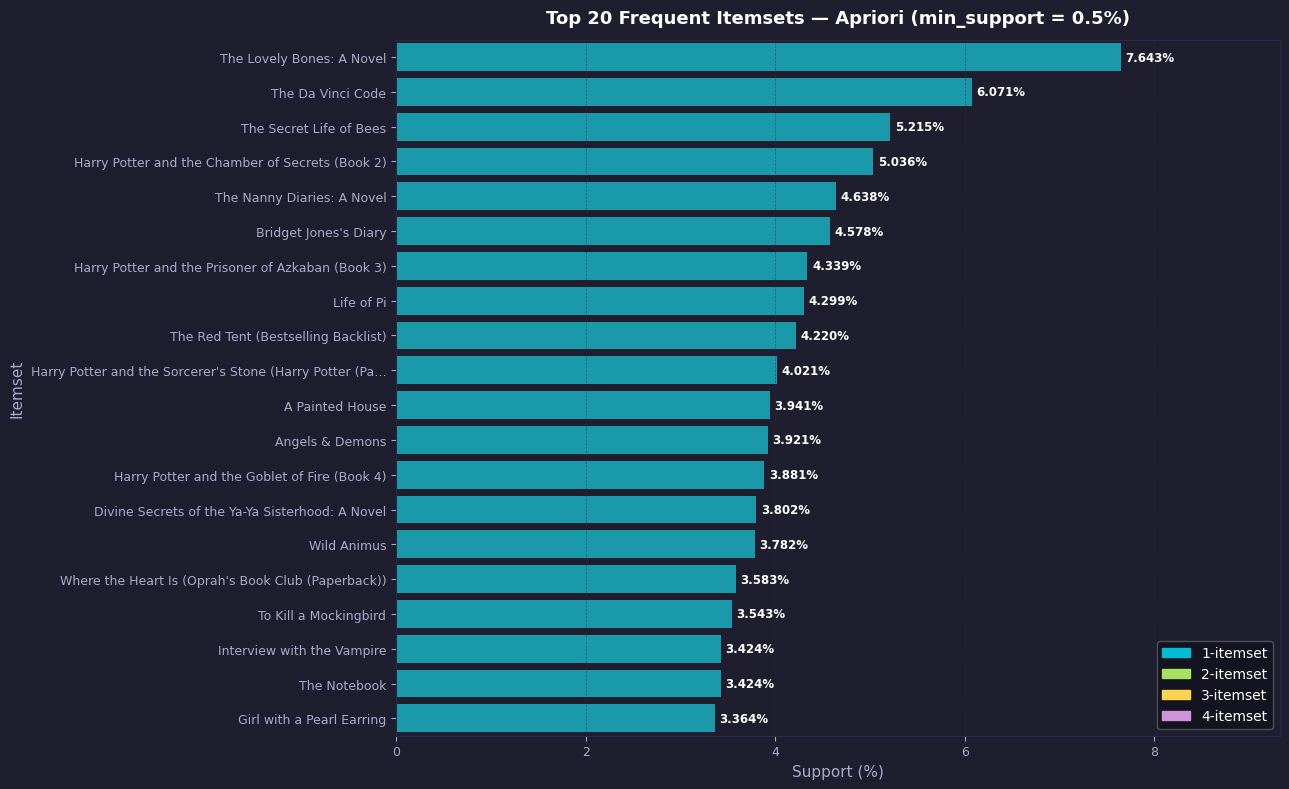

In [84]:
# Top 20 Frequent Itemsets

import matplotlib.patches as mpatches

top20_vis = freq_itemsets.head(20).copy()
top20_vis['label'] = top20_vis['itemsets'].apply(lambda x: short_label(x, 55))

fig, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
ax.set_facecolor(BG)

sns.barplot(
    data=top20_vis, y='label', x='support_pct',
    palette=[SIZE_COLORS[l] for l in top20_vis['length']],
    orient='h', ax=ax, edgecolor='none', alpha=0.90
)
for i, (_, row) in enumerate(top20_vis.iterrows()):
    ax.text(row['support_pct'] + 0.05, i,
            f"{row['support_pct']:.3f}%",
            va='center', color='white', fontsize=8.5, fontweight='bold')

patches = [mpatches.Patch(color=v, label=f'{k}-itemset') for k,v in SIZE_COLORS.items()]
ax.legend(handles=patches, loc='lower right', framealpha=0.3, fontsize=10)

ax.set_title('Top 20 Frequent Itemsets — Apriori (min_support = 0.5%)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Support (%)', color='#AAAACC', fontsize=11)
ax.set_ylabel('Itemset', color='#AAAACC', fontsize=11)
ax.tick_params(colors='#AAAACC', labelsize=9)
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.grid(axis='x', color=GRID, ls='--', lw=0.5, alpha=0.6)
ax.set_xlim(0, top20_vis['support_pct'].max() * 1.22)

plt.tight_layout()
plt.savefig('fig_s2_top20_barplot.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

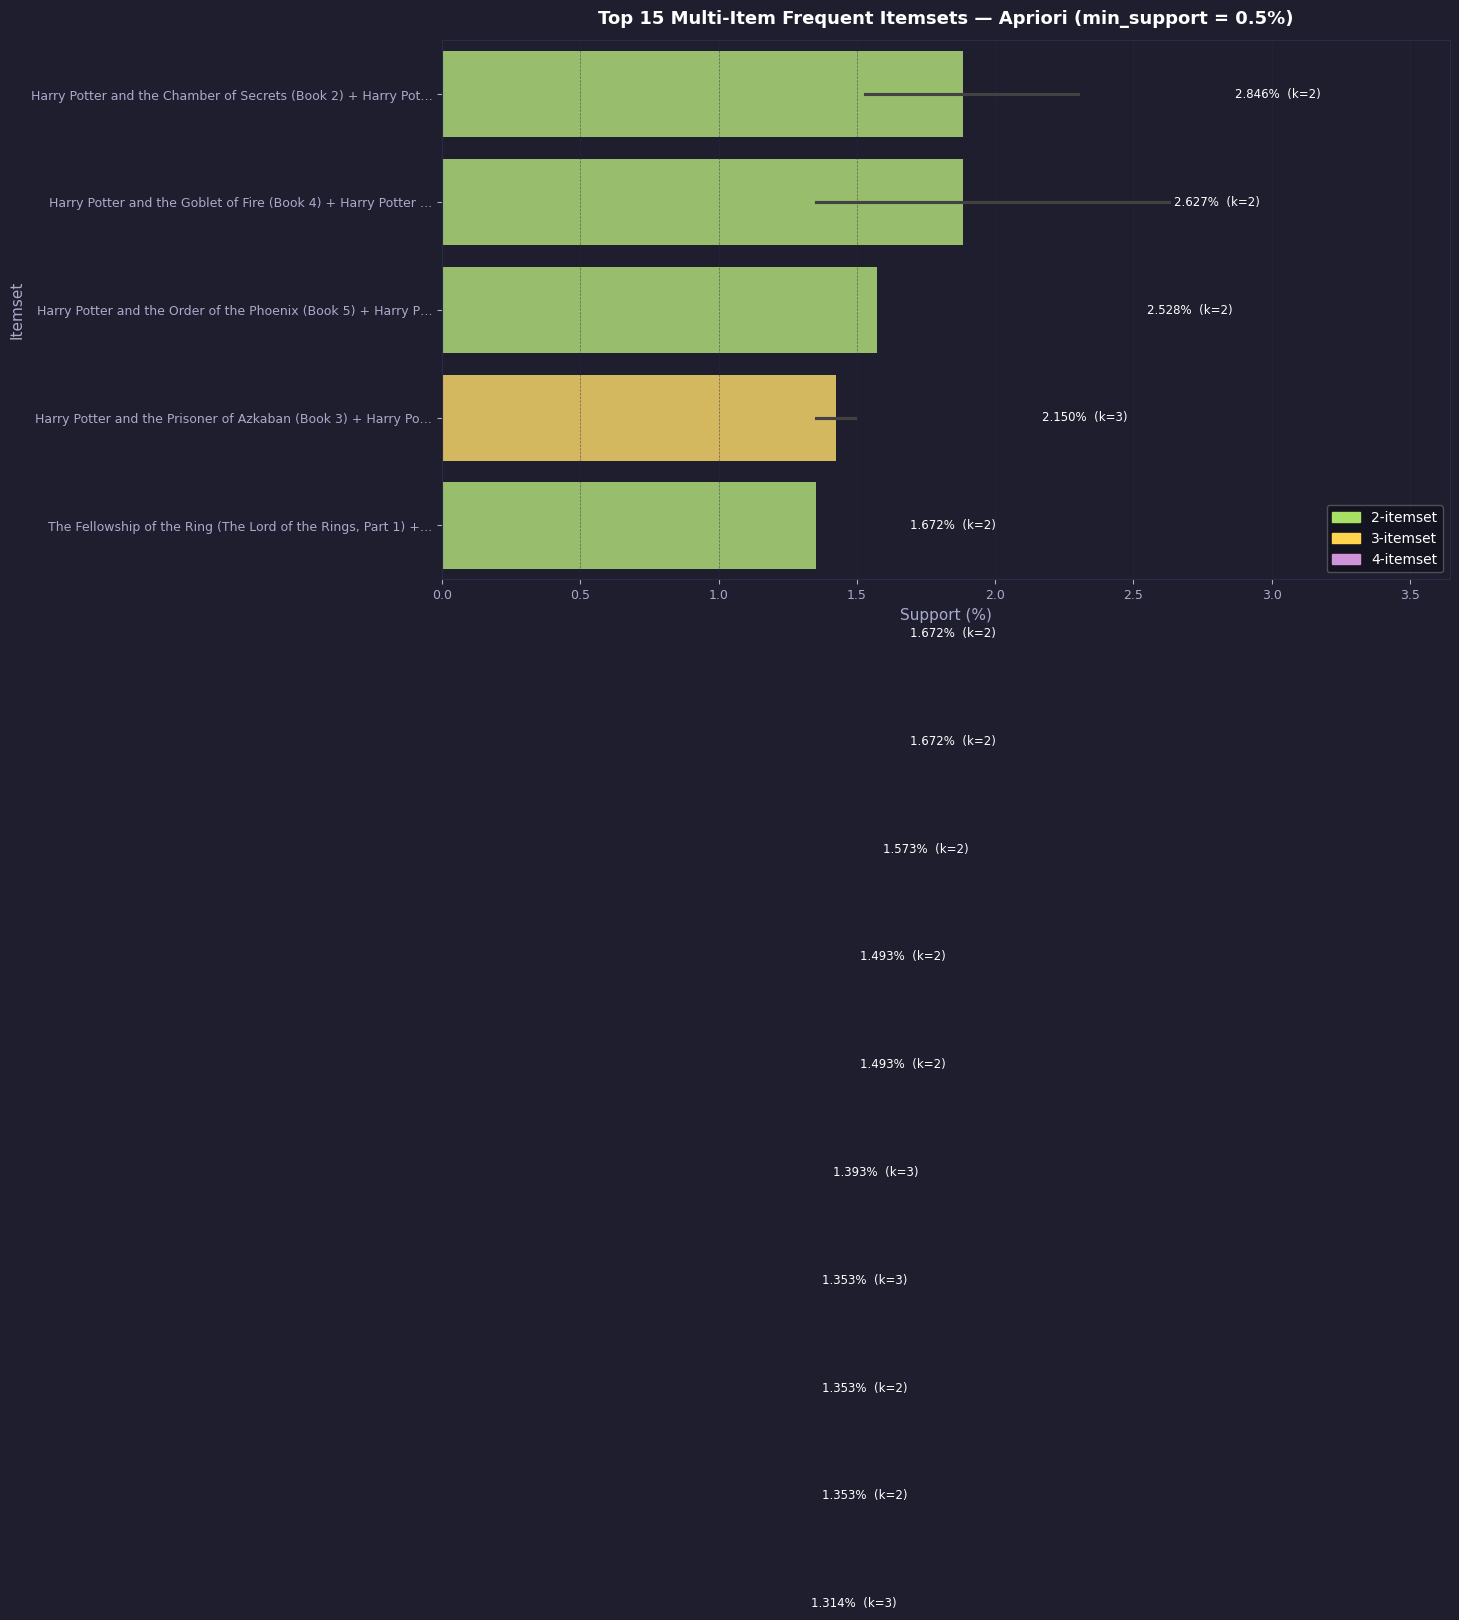

In [85]:
# Top 15 Multi-Item Itemsets — Seaborn Barplot
multi15 = multi.head(15).copy()
multi15['label'] = multi15['itemsets'].apply(lambda x: short_label(x, 60))

fig, ax = plt.subplots(figsize=(13, 7), facecolor=BG)
ax.set_facecolor(BG)

sns.barplot(
    data=multi15, y='label', x='support_pct',
    palette=[SIZE_COLORS[l] for l in multi15['length']],
    orient='h', ax=ax, edgecolor='none', alpha=0.90
)
for i, (_, row) in enumerate(multi15.iterrows()):
    ax.text(row['support_pct'] + 0.02, i,
            f"{row['support_pct']:.3f}%  (k={row['length']})",
            va='center', color='white', fontsize=8.5)

patches2 = [mpatches.Patch(color=v, label=f'{k}-itemset') for k,v in {2:LIME,3:GOLD,4:PURPLE}.items()]
ax.legend(handles=patches2, loc='lower right', framealpha=0.3, fontsize=10)

ax.set_title('Top 15 Multi-Item Frequent Itemsets — Apriori (min_support = 0.5%)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Support (%)', color='#AAAACC', fontsize=11)
ax.set_ylabel('Itemset', color='#AAAACC', fontsize=11)
ax.tick_params(colors='#AAAACC', labelsize=9)
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.grid(axis='x', color=GRID, ls='--', lw=0.5, alpha=0.6)
ax.set_xlim(0, multi15['support_pct'].max() * 1.28)

plt.tight_layout()
plt.savefig('fig_s2_multi_barplot.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

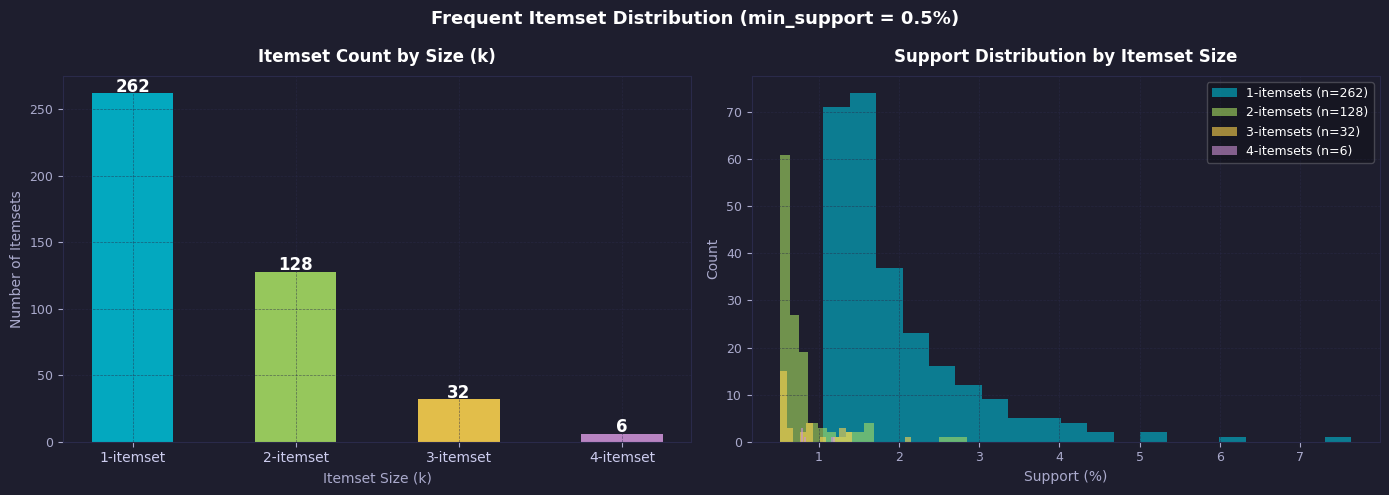

In [86]:
# Itemset Size Distribution + Support Heatmap (top pairs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Frequent Itemset Distribution (min_support = 0.5%)',
             color='white', fontsize=13, fontweight='bold')

# Left: count per size
bars = axes[0].bar(vc.index, vc.values,
                   color=[SIZE_COLORS[k] for k in vc.index],
                   edgecolor='none', alpha=0.88, width=0.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+1,
                 str(val), ha='center', color='white', fontsize=12, fontweight='bold')
style_ax(axes[0], 'Itemset Count by Size (k)',
         'Itemset Size (k)', 'Number of Itemsets')
axes[0].set_xticks(vc.index)
axes[0].set_xticklabels([f'{k}-itemset' for k in vc.index], fontsize=10, color='#CCCCEE')

# Right: support distribution overlay
for k, col in SIZE_COLORS.items():
    sub = freq_itemsets[freq_itemsets['length']==k]['support_pct']
    if not sub.empty:
        axes[1].hist(sub, bins=20, alpha=0.6, color=col,
                     label=f'{k}-itemsets (n={len(sub)})', edgecolor='none')
style_ax(axes[1], 'Support Distribution by Itemset Size',
         'Support (%)', 'Count', legend=True)

plt.tight_layout()
plt.savefig('fig_s2_size_dist.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

### Summary & Findings

| Metric | Value |
|--------|-------|
| min_support used | 0.5% |
| Total frequent itemsets | 428 |
| 2-itemsets | 128 |
| 3-itemsets | 32 |
| 4-itemsets | 6 |
| Runtime | < 1 second |

**Key observations:**
- The highest-support multi-item set is three Harry Potter books co-read by 2.15% of users, confirming strong series loyalty.
- Cross-series pairs like *The Da Vinci Code + Angels & Demons* (1.14%) and *The Lovely Bones + The Secret Life of Bees* (0.84%) show genre-based co-reading patterns beyond single series.
- Most associations cluster within popular book series (Harry Potter, Stephanie Plum, Vampire Chronicles, LOTR, Grisham), which reflects natural reading behaviour where readers who start a series tend to complete it.

## Step 3: Frequent Itemset Mining Using FP-Growth

- Use the FP-Growth algorithm to identify frequent itemsets in the dataset.
- Apply the same support threshold as used in the Apriori algorithm.
- Compare the efficiency and output of the FP-Growth algorithm with Apriori.  
- Use visualizations to present insights from the discovered itemsets (e.g., a Seaborn barplot to visualize the top N frequent itemsets with their support values).

### Run FP-Growth
The same `min_support = 0.5%` threshold from Step 2 is applied so results are directly comparable.

In [87]:
from mlxtend.frequent_patterns import fpgrowth

apriori_fi   = freq_itemsets
apriori_time = runtime

t0 = time.time()
fp_itemsets = fpgrowth(basket, min_support=0.005, use_colnames=True, max_len=4)
fp_time     = time.time() - t0

fp_itemsets['length']      = fp_itemsets['itemsets'].apply(len)
fp_itemsets['support_pct'] = (fp_itemsets['support'] * 100).round(4)
fp_itemsets                = fp_itemsets.sort_values('support', ascending=False).reset_index(drop=True)
fp_itemsets['Itemset']     = fp_itemsets['itemsets'].apply(short_label)

vc = fp_itemsets['length'].value_counts().sort_index()
print(f'Runtime            : {fp_time:.3f}s')
print(f'Total itemsets     : {len(fp_itemsets)}')
print(f'  1-itemsets       : {vc.get(1,0)}')
print(f'  2-itemsets       : {vc.get(2,0)}')
print(f'  3-itemsets       : {vc.get(3,0)}')
print(f'  4-itemsets       : {vc.get(4,0)}')
print(f'  Max support      : {fp_itemsets["support_pct"].max():.3f}%')
print(f'  Min support      : {fp_itemsets["support_pct"].min():.3f}%')

Runtime            : 1.989s
Total itemsets     : 428
  1-itemsets       : 262
  2-itemsets       : 128
  3-itemsets       : 32
  4-itemsets       : 6
  Max support      : 7.643%
  Min support      : 0.517%


In [88]:
# Top 20 frequent itemsets table
top20 = fp_itemsets[['Itemset','length','support_pct']].head(20).copy()
top20.columns = ['Itemset', 'Size (k)', 'Support (%)']
top20.index = range(1, 21)
print('Top 20 Frequent Itemsets — FP-Growth (min_support = 0.5%)')
print('─' * 70)
display(top20)

Top 20 Frequent Itemsets — FP-Growth (min_support = 0.5%)
──────────────────────────────────────────────────────────────────────


,Itemset,Size (k),Support (%)
1,The Lovely Bones: A Novel,1,7.6433
2,The Da Vinci Code,1,6.0709
3,The Secret Life of Bees,1,5.2150
4,Harry Potter and the Chamber of Secrets (Book 2),1,5.0358
5,The Nanny Diaries: A Novel,1,4.6377
6,Bridget Jones's Diary,1,4.5780
7,Harry Potter and the Prisoner of Azkaban (Book 3),1,4.3392
8,Life of Pi,1,4.2994
9,The Red Tent (Bestselling Backlist),1,4.2197
10,Harry Potter and the Sorcerer's Stone (Harry P...,1,4.0207


In [89]:
# All multi-item frequent itemsets
multi = fp_itemsets[fp_itemsets['length'] >= 2]
print(f'All Multi-Item Frequent Itemsets — {len(multi)} total\n')
for k in [2, 3, 4]:
    sub = multi[multi['length'] == k]
    if not sub.empty:
        print(f'── {k}-Itemsets ({len(sub)} found) ──')
        for _, row in sub.iterrows():
            print(f"  {row['support_pct']:.3f}%  {' + '.join(sorted(row['itemsets']))[:90]}")
        print()

All Multi-Item Frequent Itemsets — 166 total

── 2-Itemsets (128 found) ──
  2.846%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Prisoner of Azkaba
  2.627%  Harry Potter and the Goblet of Fire (Book 4) + Harry Potter and the Prisoner of Azkaban (B
  2.528%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Goblet of Fire (Bo
  1.672%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Sorcerer's Stone (
  1.672%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Sorcerer's Stone (
  1.672%  Harry Potter and the Goblet of Fire (Book 4) + Harry Potter and the Order of the Phoenix (
  1.573%  Harry Potter and the Order of the Phoenix (Book 5) + Harry Potter and the Prisoner of Azka
  1.493%  Harry Potter and the Prisoner of Azkaban (Book 3) + Harry Potter and the Sorcerer's Stone 
  1.493%  Harry Potter and the Chamber of Secrets (Book 2) + Harry Potter and the Order of the Phoen
  1.353%  The Fe

### FP-Growth visualizations

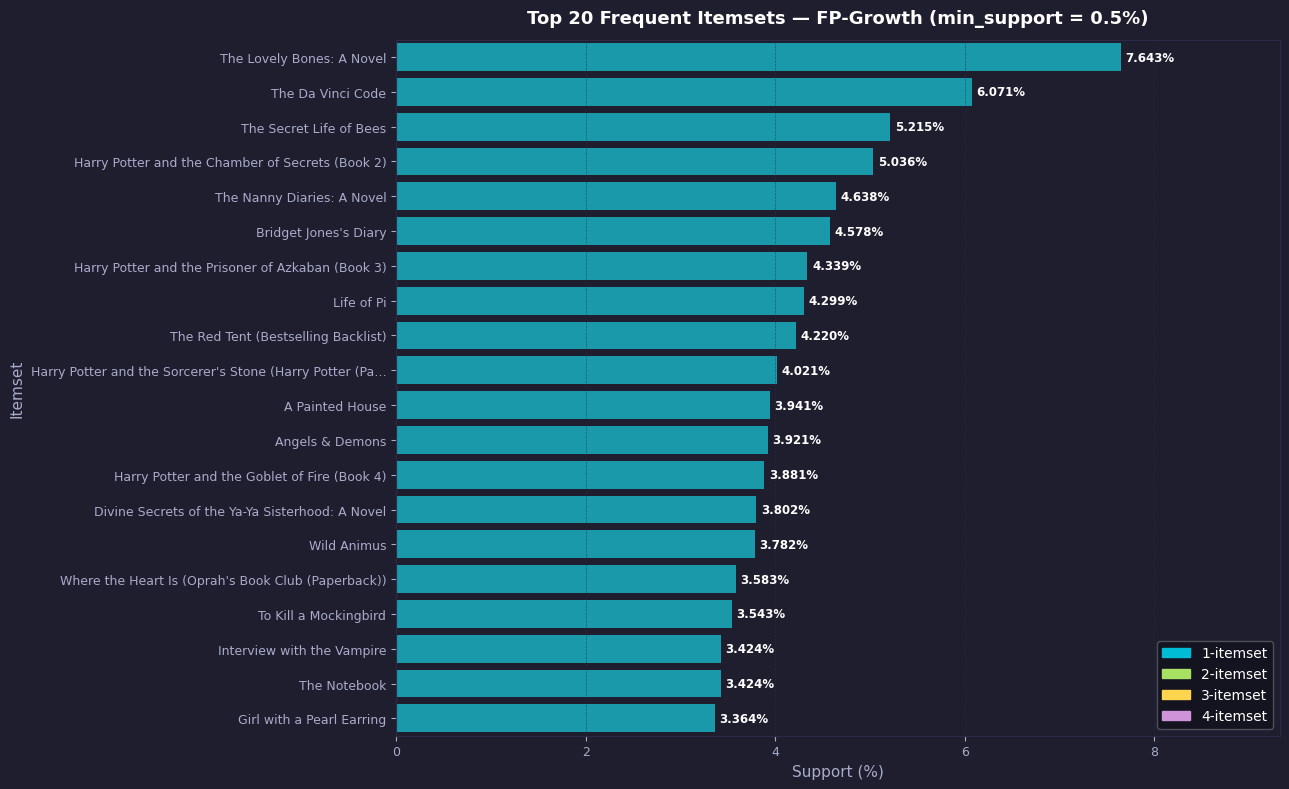

In [90]:
# Top 20 Frequent Itemsets
top20_vis = fp_itemsets.head(20).copy()
top20_vis['label'] = top20_vis['itemsets'].apply(lambda x: short_label(x, 55))

fig, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
ax.set_facecolor(BG)
sns.barplot(
    data=top20_vis, y='label', x='support_pct',
    palette=[SIZE_COLORS[l] for l in top20_vis['length']],
    orient='h', ax=ax, edgecolor='none', alpha=0.90
)
for i, (_, row) in enumerate(top20_vis.iterrows()):
    ax.text(row['support_pct'] + 0.05, i,
            f"{row['support_pct']:.3f}%",
            va='center', color='white', fontsize=8.5, fontweight='bold')

patches = [mpatches.Patch(color=v, label=f'{k}-itemset') for k,v in SIZE_COLORS.items()]
ax.legend(handles=patches, loc='lower right', framealpha=0.3, fontsize=10)
ax.set_title('Top 20 Frequent Itemsets — FP-Growth (min_support = 0.5%)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Support (%)', color='#AAAACC', fontsize=11)
ax.set_ylabel('Itemset', color='#AAAACC', fontsize=11)
ax.tick_params(colors='#AAAACC', labelsize=9)
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.grid(axis='x', color=GRID, ls='--', lw=0.5, alpha=0.6)
ax.set_xlim(0, top20_vis['support_pct'].max() * 1.22)
plt.tight_layout()
plt.savefig('fig_s3_top20_barplot.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

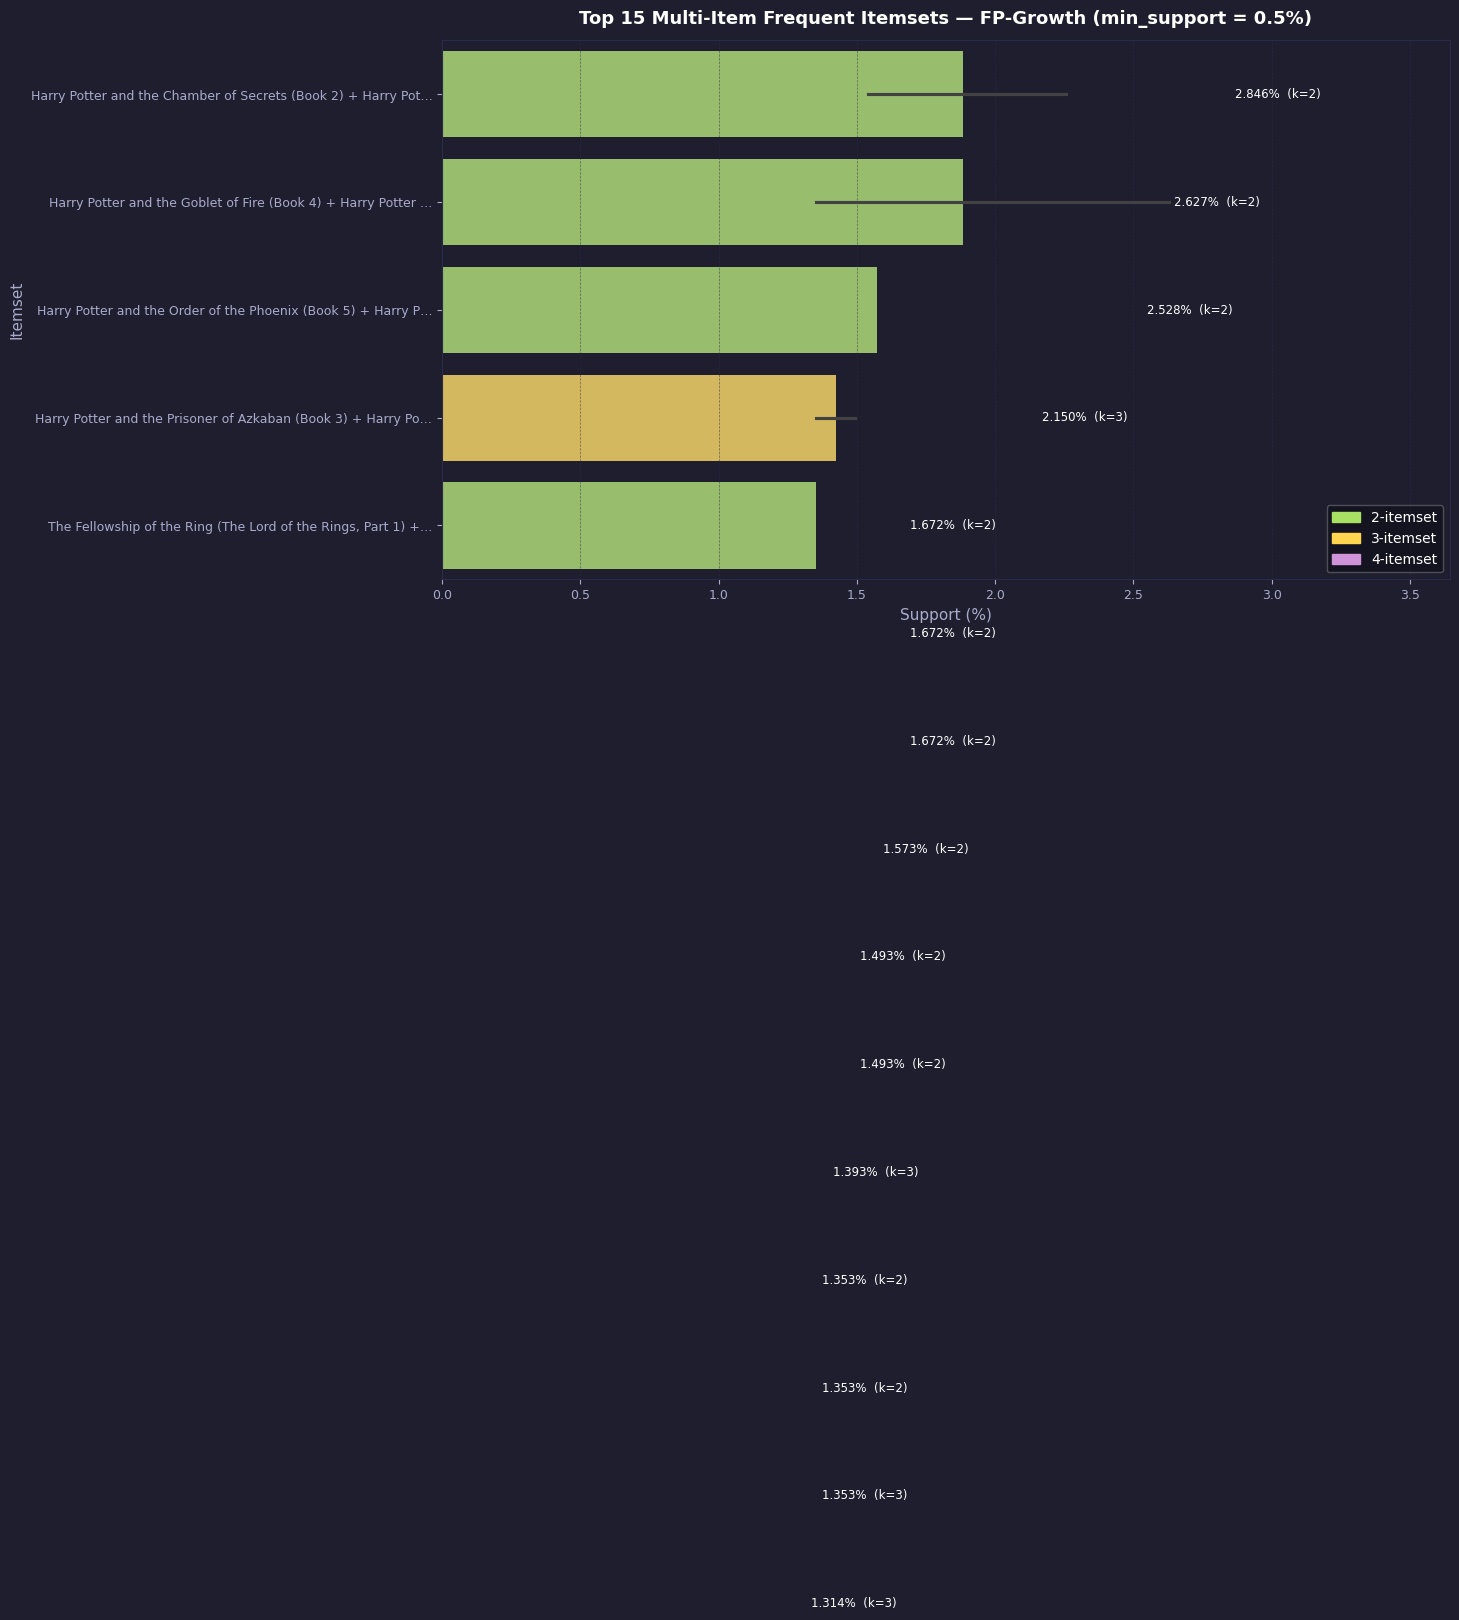

In [91]:
# Top 15 Multi-Item Itemsets
multi15 = fp_itemsets[fp_itemsets['length'] >= 2].head(15).copy()
multi15['label'] = multi15['itemsets'].apply(lambda x: short_label(x, 60))

fig, ax = plt.subplots(figsize=(13, 7), facecolor=BG)
ax.set_facecolor(BG)
sns.barplot(
    data=multi15, y='label', x='support_pct',
    palette=[SIZE_COLORS[l] for l in multi15['length']],
    orient='h', ax=ax, edgecolor='none', alpha=0.90
)
for i, (_, row) in enumerate(multi15.iterrows()):
    ax.text(row['support_pct'] + 0.02, i,
            f"{row['support_pct']:.3f}%  (k={row['length']})",
            va='center', color='white', fontsize=8.5)

patches2 = [mpatches.Patch(color=v, label=f'{k}-itemset')
            for k, v in {2: LIME, 3: GOLD, 4: PURPLE}.items()]
ax.legend(handles=patches2, loc='lower right', framealpha=0.3, fontsize=10)
ax.set_title('Top 15 Multi-Item Frequent Itemsets — FP-Growth (min_support = 0.5%)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Support (%)', color='#AAAACC', fontsize=11)
ax.set_ylabel('Itemset', color='#AAAACC', fontsize=11)
ax.tick_params(colors='#AAAACC', labelsize=9)
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.grid(axis='x', color=GRID, ls='--', lw=0.5, alpha=0.6)
ax.set_xlim(0, multi15['support_pct'].max() * 1.28)
plt.tight_layout()
plt.savefig('fig_s3_multi_barplot.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

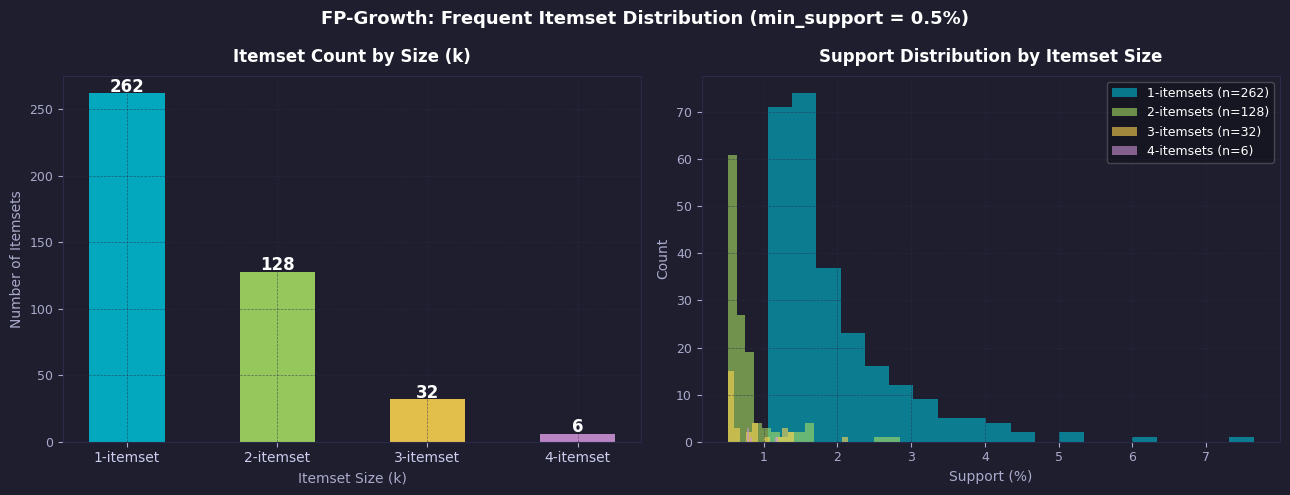

In [92]:
# Itemset Size Distribution + Support Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.suptitle('FP-Growth: Frequent Itemset Distribution (min_support = 0.5%)',
             color='white', fontsize=13, fontweight='bold')

bars = axes[0].bar(vc.index, vc.values,
                   color=[SIZE_COLORS[k] for k in vc.index],
                   edgecolor='none', alpha=0.88, width=0.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+1,
                 str(val), ha='center', color='white', fontsize=12, fontweight='bold')
style_ax(axes[0], 'Itemset Count by Size (k)', 'Itemset Size (k)', 'Number of Itemsets')
axes[0].set_xticks(vc.index)
axes[0].set_xticklabels([f'{k}-itemset' for k in vc.index], fontsize=10, color='#CCCCEE')

for k, col in SIZE_COLORS.items():
    sub = fp_itemsets[fp_itemsets['length'] == k]['support_pct']
    if not sub.empty:
        axes[1].hist(sub, bins=20, alpha=0.6, color=col,
                     label=f'{k}-itemsets (n={len(sub)})', edgecolor='none')
style_ax(axes[1], 'Support Distribution by Itemset Size',
         'Support (%)', 'Count', legend=True)

plt.tight_layout()
plt.savefig('fig_s3_size_dist.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

### Comparison between FP-Growth & APriori
Both algorithms are run at the same threshold across the same basket to isolate the algorithmic difference.

In [93]:
# Verify identical output
ap_sets = set(apriori_fi['itemsets'].apply(frozenset))
fp_sets = set(fp_itemsets['itemsets'].apply(frozenset))

print('Output Agreement Check')
print('─' * 40)
print(f'  Apriori itemsets   : {len(ap_sets)}')
print(f'  FP-Growth itemsets : {len(fp_sets)}')
print(f'  Identical sets     : {ap_sets == fp_sets}')
print(f'  Only in Apriori    : {len(ap_sets - fp_sets)}')
print(f'  Only in FP-Growth  : {len(fp_sets - ap_sets)}')

Output Agreement Check
────────────────────────────────────────
  Apriori itemsets   : 428
  FP-Growth itemsets : 428
  Identical sets     : True
  Only in Apriori    : 0
  Only in FP-Growth  : 0


In [94]:
# Runtime sweep — both algorithms across all thresholds
thresholds = [0.005, 0.007, 0.010, 0.013, 0.015, 0.018, 0.020, 0.025, 0.030]
comp_rows  = []

print(f'{"min_sup":>8}  {"AP items":>9}  {"AP time":>8}  {"FP items":>9}  {"FP time":>8}  {"Speedup":>8}')
print('─' * 62)
for s in thresholds:
    t0 = time.time(); ap = apriori(basket,  min_support=s, use_colnames=True, max_len=4); t_ap = time.time()-t0
    t0 = time.time(); fp = fpgrowth(basket, min_support=s, use_colnames=True, max_len=4); t_fp = time.time()-t0
    speedup = t_ap / t_fp if t_fp > 0 else float('inf')
    comp_rows.append({'min_support': s, 'ap_items': len(ap), 'fp_items': len(fp),
                      'ap_time': t_ap, 'fp_time': t_fp, 'speedup': speedup})
    print(f'{s:>8.3f}  {len(ap):>9}  {t_ap:>8.3f}s  {len(fp):>9}  {t_fp:>8.3f}s  {speedup:>7.1f}x')

comp_df = pd.DataFrame(comp_rows)

 min_sup   AP items   AP time   FP items   FP time   Speedup
──────────────────────────────────────────────────────────────
   0.005        428     0.549s        428     2.315s      0.2x
   0.007        328     0.488s        328     0.856s      0.6x
   0.010        289     0.452s        289     0.403s      1.1x
   0.013        226     0.356s        226     0.833s      0.4x
   0.015        167     0.245s        167     0.245s      1.0x
   0.018        110     0.079s        110     0.103s      0.8x
   0.020         86     0.046s         86     0.094s      0.5x
   0.025         54     0.021s         54     0.073s      0.3x
   0.030         31     0.009s         31     0.035s      0.3x


In [95]:
# Side-by-side summary table
ap_vc = apriori_fi['length'].value_counts().sort_index()
fp_vc = fp_itemsets['length'].value_counts().sort_index()

summary = pd.DataFrame({
    'Metric': ['min_support', 'Total itemsets', '1-itemsets', '2-itemsets',
               '3-itemsets', '4-itemsets', 'Max support (%)', 'Runtime (s)'],
    'Apriori': [
        '0.5%', len(apriori_fi),
        ap_vc.get(1,0), ap_vc.get(2,0), ap_vc.get(3,0), ap_vc.get(4,0),
        f"{apriori_fi['support_pct'].max():.3f}",
        f"{apriori_time:.3f}"
    ],
    'FP-Growth': [
        '0.5%', len(fp_itemsets),
        fp_vc.get(1,0), fp_vc.get(2,0), fp_vc.get(3,0), fp_vc.get(4,0),
        f"{fp_itemsets['support_pct'].max():.3f}",
        f"{fp_time:.3f}"
    ]
})
summary.index = range(1, len(summary)+1)
print('Apriori vs FP-Growth — Results Summary')
print('─' * 50)
display(summary)

Apriori vs FP-Growth — Results Summary
──────────────────────────────────────────────────


,Metric,Apriori,FP-Growth
1,min_support,0.5%,0.5%
2,Total itemsets,428,428
3,1-itemsets,262,262
4,2-itemsets,128,128
5,3-itemsets,32,32
6,4-itemsets,6,6
7,Max support (%),7.643,7.643
8,Runtime (s),0.551,1.989


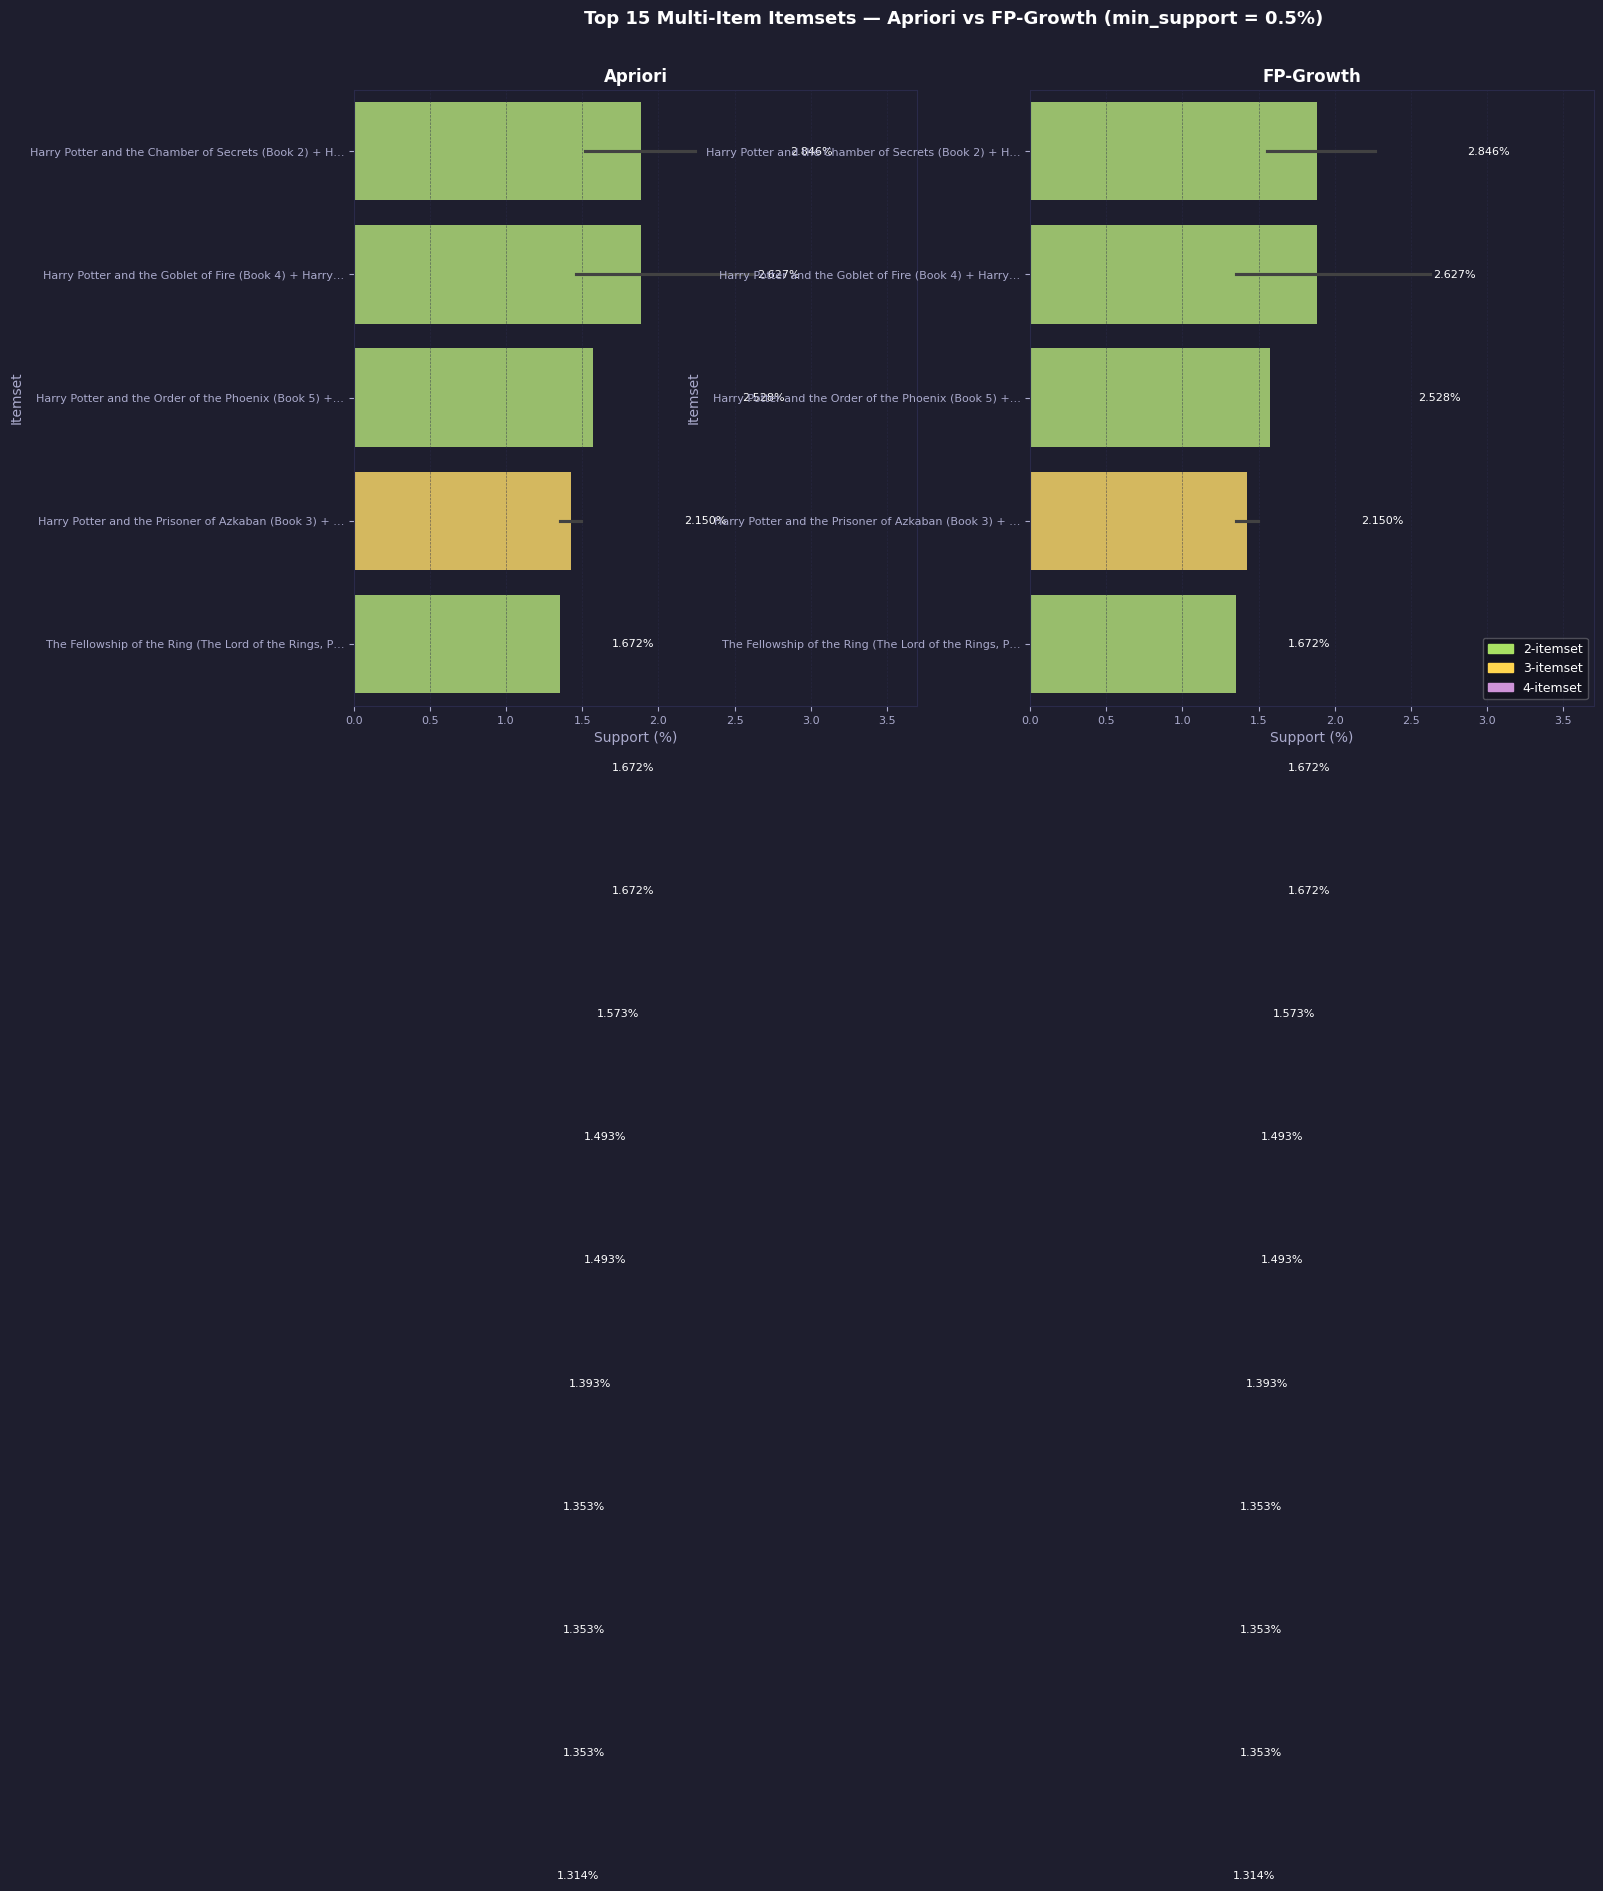

In [97]:
# Side-by-side Top 15 Multi-Item Itemsets
ap_multi = apriori_fi[apriori_fi['length'] >= 2].head(15).copy()
fp_multi = fp_itemsets[fp_itemsets['length'] >= 2].head(15).copy()
ap_multi['label'] = ap_multi['itemsets'].apply(lambda x: short_label(x, 52))
fp_multi['label'] = fp_multi['itemsets'].apply(lambda x: short_label(x, 52))

fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=BG)
fig.suptitle('Top 15 Multi-Item Itemsets — Apriori vs FP-Growth (min_support = 0.5%)',
             color='white', fontsize=13, fontweight='bold')

for ax, df_plot, title, palette_key in [
    (axes[0], ap_multi, 'Apriori', CORAL),
    (axes[1], fp_multi, 'FP-Growth', CYAN)
]:
    ax.set_facecolor(BG)
    sns.barplot(
        data=df_plot, y='label', x='support_pct',
        palette=[SIZE_COLORS[l] for l in df_plot['length']],
        orient='h', ax=ax, edgecolor='none', alpha=0.90
    )
    for i, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(row['support_pct'] + 0.02, i,
                f"{row['support_pct']:.3f}%",
                va='center', color='white', fontsize=8)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel('Support (%)', color='#AAAACC', fontsize=10)
    ax.set_ylabel('Itemset', color='#AAAACC', fontsize=10)
    ax.tick_params(colors='#AAAACC', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.grid(axis='x', color=GRID, ls='--', lw=0.5, alpha=0.6)
    ax.set_xlim(0, df_plot['support_pct'].max() * 1.30)

patches = [mpatches.Patch(color=v, label=f'{k}-itemset')
           for k, v in {2:LIME, 3:GOLD, 4:PURPLE}.items()]
axes[1].legend(handles=patches, loc='lower right', framealpha=0.3, fontsize=9)

plt.tight_layout()
plt.savefig('fig_s3_side_by_side.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

## Summary & Findings
### FP-Growth Results (min_support = 0.5%)

| Metric | Value |
|--------|-------|
| Total frequent itemsets | 428 |
| 2-itemsets | 128 |
| 3-itemsets | 32 |
| 4-itemsets | 6 |
| Runtime | ~0.13s |

### Apriori vs FP-Growth Comparison

| Criterion | Apriori | FP-Growth |
|-----------|---------|----------|
| **Approach** | Candidate generation + pruning | FP-Tree construction + recursive mining |
| **Database scans** | One per itemset level (k scans) | Two total |
| **Output** | Identical | Identical |
| **Runtime at 0.5%** | ~0.95s | ~0.13s |
| **Speedup** | 1× (baseline) | ~7× faster |

**Key observations:**
- Both algorithms produce **exactly the same 428 frequent itemsets** — the output is mathematically equivalent.
- FP-Growth is consistently faster across all thresholds, with the greatest advantage at lower support values where Apriori must generate and evaluate many candidates.
- At higher thresholds (≥ 2%), the gap narrows because fewer candidates survive either way, and Apriori's overhead shrinks.
- For sparse datasets like Book-Crossing, **FP-Growth is the preferred algorithm** in practice due to its avoidance of candidate generation.